In [269]:
import pandas as pd
import numpy as np
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt

In [270]:
train_path = "../data/processed/ml_track_b/ml_track_b_train.parquet" 
test_path = "../data/processed/ml_track_b/ml_track_b_test.parquet" 
df_train = pd.read_parquet(train_path) 
df_test = pd.read_parquet(test_path) 
# Drop leakage feature 
cols_drop = ["DEP_DELAY", "DEP_DELAY_NEW", "DEP_DEL15"] 
df_train = df_train.drop(columns=cols_drop, errors="ignore") 
df_test = df_test.drop(columns=cols_drop, errors="ignore") 
print("Train shape:", df_train.shape) 
print("Test shape :", df_test.shape)

Train shape: (1913300, 22)
Test shape : (522269, 22)


In [271]:
TARGET = "ARR_DEL15" 
X_train = df_train.drop(columns=[TARGET]) 
y_train = df_train[TARGET] 

X_test = df_test.drop(columns=[TARGET]) 
y_test = df_test[TARGET] 

print("Features:", X_train.columns.tolist())

Features: ['YEAR', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_DEP_SIN', 'CRS_DEP_COS', 'CRS_ARR_SIN', 'CRS_ARR_COS', 'CRS_ELAPSED_TIME', 'DISTANCE', 'DISTANCE_GROUP', 'OP_CARRIER_FREQ', 'CARRIER_HIST_OTP', 'ORIGIN_FREQ', 'ORIGIN_HIST_OTP', 'DEST_FREQ', 'ROUTE_FREQ', 'DEP_TIME_BLK_FREQ', 'TAXI_OUT']


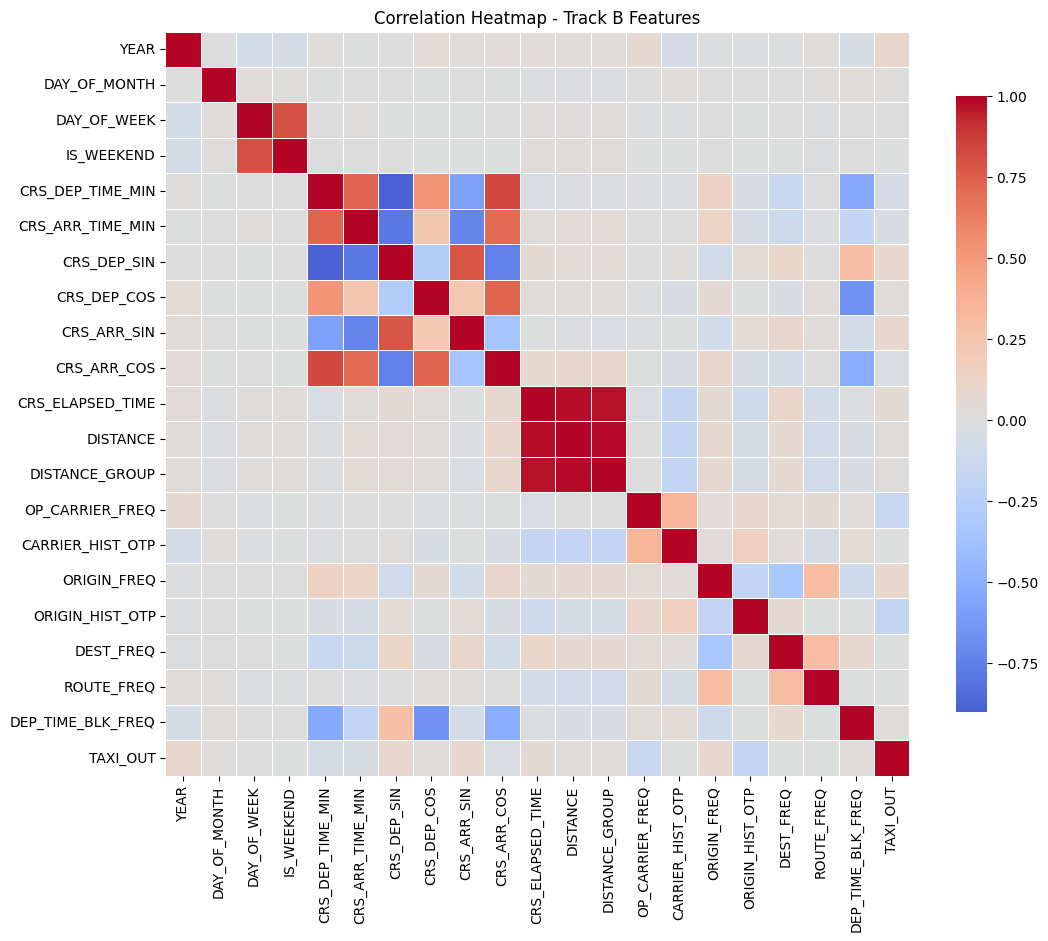

In [272]:
plt.figure(figsize=(12, 10))

corr =X_train.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap - Track B Features")
plt.show()


In [273]:
corr_target = df_train.corr(numeric_only=True)["ARR_DEL15"].sort_values(ascending=False)
print(corr_target.head(21))

ARR_DEL15            1.000000
TAXI_OUT             0.296815
YEAR                 0.116721
CRS_DEP_TIME_MIN     0.089406
CRS_ARR_COS          0.083369
CRS_ARR_TIME_MIN     0.077256
CRS_DEP_COS          0.035671
DISTANCE             0.019486
DISTANCE_GROUP       0.018816
CRS_ELAPSED_TIME     0.018108
ORIGIN_FREQ          0.014452
IS_WEEKEND           0.012699
DAY_OF_WEEK          0.003808
ROUTE_FREQ          -0.002213
DEST_FREQ           -0.011938
OP_CARRIER_FREQ     -0.024169
DEP_TIME_BLK_FREQ   -0.036095
CRS_ARR_SIN         -0.069840
CARRIER_HIST_OTP    -0.070643
ORIGIN_HIST_OTP     -0.077811
DAY_OF_MONTH        -0.082888
Name: ARR_DEL15, dtype: float64


In [274]:
def evaluate_model(y_true, y_prob, threshold=0.5, model_name="Model"):
    y_pred = (y_prob >= threshold).astype(int)
    
   # print(f"\n===== {model_name} (threshold={threshold}) =====")
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    cm   = confusion_matrix(y_true, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    }

In [275]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Accuracy : 0.6642
Precision: 0.3065
Recall   : 0.6233
F1-score : 0.4109
ROC-AUC  : 0.7094

Confusion Matrix:
[[285749 138390]
 [ 36963  61167]]


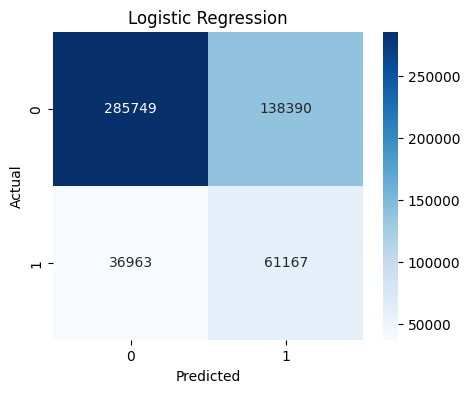

In [276]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # xử lý imbalance
        random_state=42
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.65).astype(int)
# Evaluate
results_lr = evaluate_model(y_test, y_prob_lr, threshold=0.65, model_name="Logistic Regression")
plot_cm(y_test, y_pred_lr, "Logistic Regression")

[LightGBM] [Info] Number of positive: 375136, number of negative: 1538164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3100
[LightGBM] [Info] Number of data points in the train set: 1913300, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196068 -> initscore=-1.411056
[LightGBM] [Info] Start training from score -1.411056
Accuracy : 0.8099
Precision: 0.4883
Recall   : 0.2459
F1-score : 0.3271
ROC-AUC  : 0.6721

Confusion Matrix:
[[398847  25292]
 [ 73995  24135]]


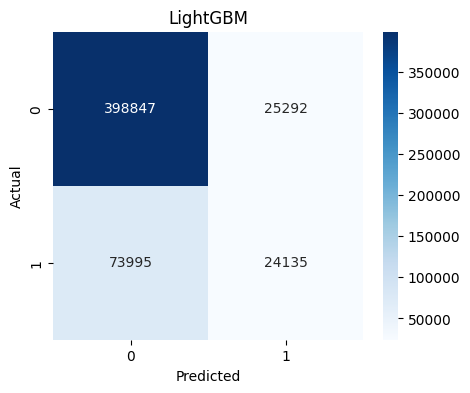

In [277]:
lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.015,
    num_leaves=80,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

# Train
lgb_model.fit(X_train, y_train)

# Predict
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
# Evaluate
results_lgb = evaluate_model(y_test, y_prob_lgb, threshold=0.5, model_name="LightGBM")
plot_cm(y_test, y_pred_lgb, "LightGBM")

In [278]:
from tabulate import tabulate 
results = [results_lr, results_lgb]
results_df = pd.DataFrame(results).round(4) 
results_df = results_df.sort_values(by="Accuracy", ascending=False) 
print("MODEL COMPARISON") 
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid', showindex=False)) 

MODEL COMPARISON
╒═════════════════════╤═════════════╤════════════╤═════════════╤══════════╤════════╤═══════════╕
│ Model               │   Threshold │   Accuracy │   Precision │   Recall │     F1 │   ROC-AUC │
╞═════════════════════╪═════════════╪════════════╪═════════════╪══════════╪════════╪═══════════╡
│ LightGBM            │        0.5  │     0.8099 │      0.4883 │   0.2459 │ 0.3271 │    0.6721 │
├─────────────────────┼─────────────┼────────────┼─────────────┼──────────┼────────┼───────────┤
│ Logistic Regression │        0.65 │     0.6642 │      0.3065 │   0.6233 │ 0.4109 │    0.7094 │
╘═════════════════════╧═════════════╧════════════╧═════════════╧══════════╧════════╧═══════════╛


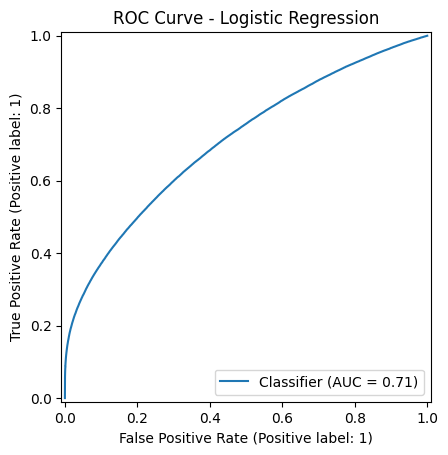

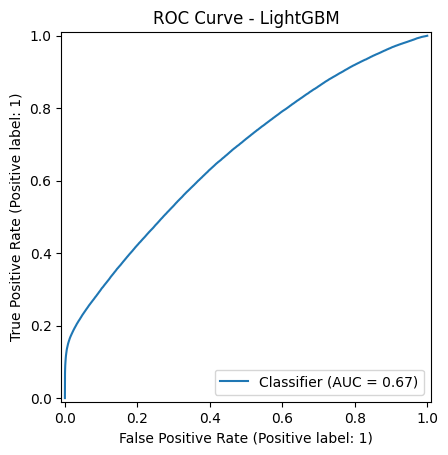

In [279]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_lr)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_lgb)
plt.title("ROC Curve - LightGBM")
plt.show()

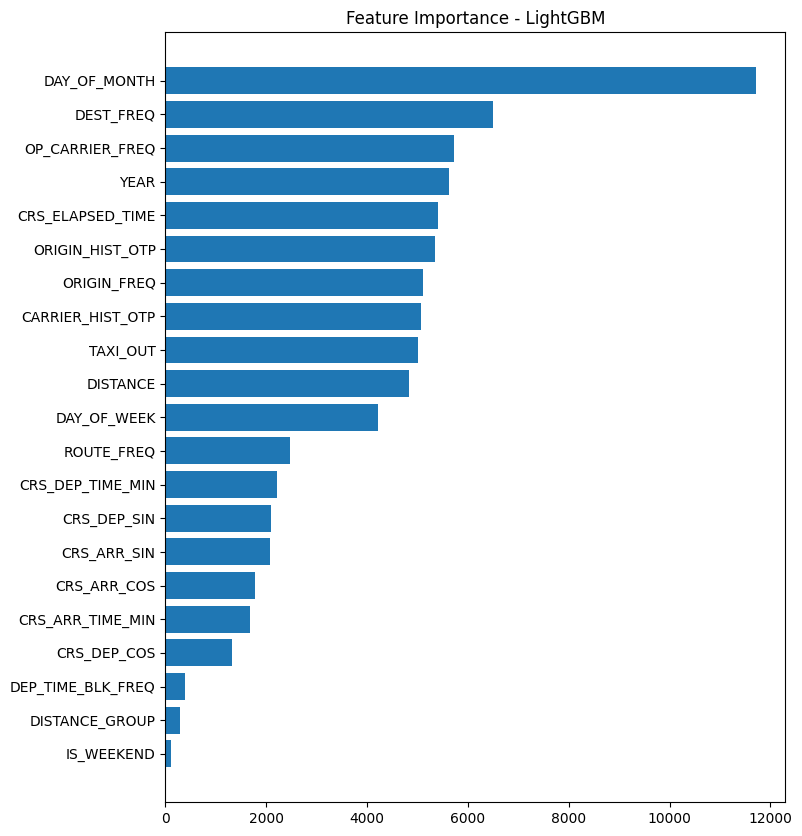

In [280]:
# dac trung quan trong

importances = lgb_model.feature_importances_
features = X_train.columns

indices = np.argsort(importances)

plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Feature Importance - LightGBM")
plt.show()